In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import os
import re
import glob
import ast
import numpy as np
import pandas as pd
from scipy.stats import entropy, wasserstein_distance
from scipy.spatial.distance import cosine
from scipy.special import kl_div
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from xgboost import XGBClassifier
from huggingface_hub import snapshot_download
import warnings

# Suppress warnings for clean output
warnings.filterwarnings('ignore')

print("==================================================")
print("PHASE 1: DOWNLOADING & PARSING DR-MUSIC DATA")
print("==================================================")

repo_path = snapshot_download(
    repo_id="BreathSense/BreathSense", 
    repo_type="dataset", 
    allow_patterns="data/**/*drmusic.csv"
)

all_files = glob.glob(f"{repo_path}/data/**/*drmusic.csv", recursive=True)
data_dict = {}

for file_path in all_files:
    activity = os.path.basename(os.path.dirname(file_path))
    match = re.search(r'(p\d+)', os.path.basename(file_path), re.IGNORECASE)
    if not match: continue
    person_id = match.group(1).lower()
    
    if person_id not in data_dict: data_dict[person_id] = {}
    data_dict[person_id][activity] = pd.read_csv(file_path).values.tolist()

final_df = pd.DataFrame.from_dict(data_dict, orient='index')
desired_columns = ['rest', 'walk', 'run', 'stairs']
existing_columns = [col for col in desired_columns if col in final_df.columns]
final_df = final_df[existing_columns]
final_df = final_df.loc[sorted(final_df.index, key=lambda x: int(x.replace('p', '')))]

# ==========================================
# FIX: DYNAMIC CLASS ALLOCATION FOR ALL 108 PARTICIPANTS
# ==========================================
gym_idx = [x-1 for x in [2, 5, 7, 10, 13, 20, 30, 33, 40, 44, 48, 50, 52, 63, 64, 68, 69, 79, 82, 86, 89]]
sports_idx = [x-1 for x in [3, 6, 9, 11, 12, 22, 25, 37, 43, 49, 53, 54, 55, 65, 70, 76, 78, 81, 87, 88]]
smoker_idx = [x-1 for x in [14, 15, 16, 17, 18, 19, 23, 27, 29, 32, 36, 42, 46, 60, 61, 62, 74, 75]]

# We capture everyone in the dataset, no matter how large it is
all_participants = set(range(len(final_df)))
normal_idx = list(all_participants - set(gym_idx) - set(sports_idx) - set(smoker_idx))

class_map = {}
for pid in normal_idx: class_map[pid] = 0
for pid in gym_idx: class_map[pid] = 1
for pid in sports_idx: class_map[pid] = 2

print(f"Dataset Loaded with {len(final_df)} total participants. Initializing Engine...")

print("\n==================================================")
print("PHASE 2: DR-MUSIC FEATURE EXTRACTION ENGINE")
print("==================================================")

class RadarFeatureExtractor:
    def extract_static_features(self, dr_matrix):
        dr_matrix = np.abs(dr_matrix) + 1e-9 
        
        spatial_energy = np.sum(dr_matrix, axis=0)
        spatial_prob = spatial_energy / np.sum(spatial_energy)
        
        spatial_entropy = entropy(spatial_prob)
        centroid = np.sum(np.arange(len(spatial_prob)) * spatial_prob)
        spatial_variance = np.sum(((np.arange(len(spatial_prob)) - centroid) ** 2) * spatial_prob)
        
        frame_energy = np.sum(dr_matrix, axis=1)
        temporal_stability = np.std(frame_energy) / (np.mean(frame_energy) + 1e-9)
        
        if dr_matrix.shape[0] > 1:
            correlations = [np.corrcoef(dr_matrix[i], dr_matrix[i-1])[0,1] for i in range(1, dr_matrix.shape[0])]
            inter_frame_corr = np.nanmean(correlations)
        else:
            inter_frame_corr = 0.0
            
        return np.array([spatial_entropy, centroid, spatial_variance, temporal_stability, inter_frame_corr])

    def calculate_transitions(self, features_A, features_B):
        cos_dist = cosine(features_A, features_B)
        wass_dist = wasserstein_distance(features_A, features_B)
        
        prob_A = np.exp(features_A) / np.sum(np.exp(features_A))
        prob_B = np.exp(features_B) / np.sum(np.exp(features_B))
        kl_distance = np.sum(kl_div(prob_A, prob_B))
        
        return [cos_dist, wass_dist, kl_distance]

extractor = RadarFeatureExtractor()
X_master = []
y_master = []

for pid in range(len(final_df)):
    if pid in smoker_idx: continue 
    
    # FIX: Lock in the label before doing any math to guarantee atomic arrays
    if pid not in class_map: continue
    target_label = class_map[pid]
        
    participant_features = []
    state_feature_dict = {}
    
    try:
        for activity in ['rest', 'walk', 'run', 'stairs']:
            raw_data = final_df.iloc[pid][activity]
            
            if isinstance(raw_data, str): 
                try: raw_data = ast.literal_eval(raw_data)
                except: raw_data = eval(raw_data) 
                
            dr_matrix = np.array(raw_data)
            
            if dr_matrix.ndim == 1:
                bins = 256 if len(dr_matrix) % 256 == 0 else min(len(dr_matrix), 128)
                dr_matrix = dr_matrix.reshape(-1, bins)
            
            state_features = extractor.extract_static_features(dr_matrix)
            state_feature_dict[activity] = state_features
            participant_features.extend(state_features)
            
        trans_rest_walk = extractor.calculate_transitions(state_feature_dict['rest'], state_feature_dict['walk'])
        trans_walk_run = extractor.calculate_transitions(state_feature_dict['walk'], state_feature_dict['run'])
        trans_run_stairs = extractor.calculate_transitions(state_feature_dict['run'], state_feature_dict['stairs'])
        trans_run_rest = extractor.calculate_transitions(state_feature_dict['run'], state_feature_dict['rest']) 
        
        participant_features.extend(trans_rest_walk)
        participant_features.extend(trans_walk_run)
        participant_features.extend(trans_run_stairs)
        participant_features.extend(trans_run_rest)
        
        # FIX: Atomic append ensures X and y NEVER get out of sync
        X_master.append(participant_features)
        y_master.append(target_label)
        
    except Exception as e:
        continue 

X_final = np.array(X_master)
y_final = np.array(y_master)
X_final = np.nan_to_num(X_final, nan=0.0, posinf=0.0, neginf=0.0)

print(f"Successfully engineered {X_final.shape[1]} features for {len(y_final)} clean participants.")

print("\n==================================================")
print("PHASE 3: GENUINE 5-FOLD XGBOOST EVALUATION")
print("==================================================")

honest_predictions = np.zeros_like(y_final)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold = 1
for train_index, test_index in skf.split(X_final, y_final):
    X_train, X_test = X_final[train_index], X_final[test_index]
    y_train, y_test = y_final[train_index], y_final[test_index]
    
    xgb_model = XGBClassifier(
        objective='multi:softmax', 
        num_class=3,
        max_depth=5,
        learning_rate=0.05,
        n_estimators=150,
        random_state=42
    )
    xgb_model.fit(X_train, y_train)
    test_preds = xgb_model.predict(X_test)
    honest_predictions[test_index] = test_preds
    fold += 1

final_acc = accuracy_score(y_final, honest_predictions)

print(f"\nFINAL GENUINE TRANSITION ACCURACY: {final_acc * 100:.2f}%\n")

target_names = ['Normal', 'Gym', 'Sports']
print("Classification Report:")
print(classification_report(y_final, honest_predictions, target_names=target_names))

print("Confusion Matrix:")
cm_df = pd.DataFrame(
    confusion_matrix(y_final, honest_predictions), 
    index=[f'True {n}' for n in target_names], 
    columns=[f'Pred {n}' for n in target_names]
)
print(cm_df)

PHASE 1: DOWNLOADING & PARSING DR-MUSIC DATA


Fetching ... files: 0it [00:00, ?it/s]

Dataset Loaded with 108 total participants. Initializing Engine...

PHASE 2: DR-MUSIC FEATURE EXTRACTION ENGINE
Successfully engineered 32 features for 90 clean participants.

PHASE 3: GENUINE 5-FOLD XGBOOST EVALUATION

FINAL GENUINE TRANSITION ACCURACY: 48.89%

Classification Report:
              precision    recall  f1-score   support

      Normal       0.63      0.69      0.66        49
         Gym       0.31      0.24      0.27        21
      Sports       0.25      0.25      0.25        20

    accuracy                           0.49        90
   macro avg       0.40      0.39      0.39        90
weighted avg       0.47      0.49      0.48        90

Confusion Matrix:
             Pred Normal  Pred Gym  Pred Sports
True Normal           34         6            9
True Gym              10         5            6
True Sports           10         5            5



VISUALIZATION: PHASE DATA (1 NORMAL, 1 GYM, 1 SPORTS)


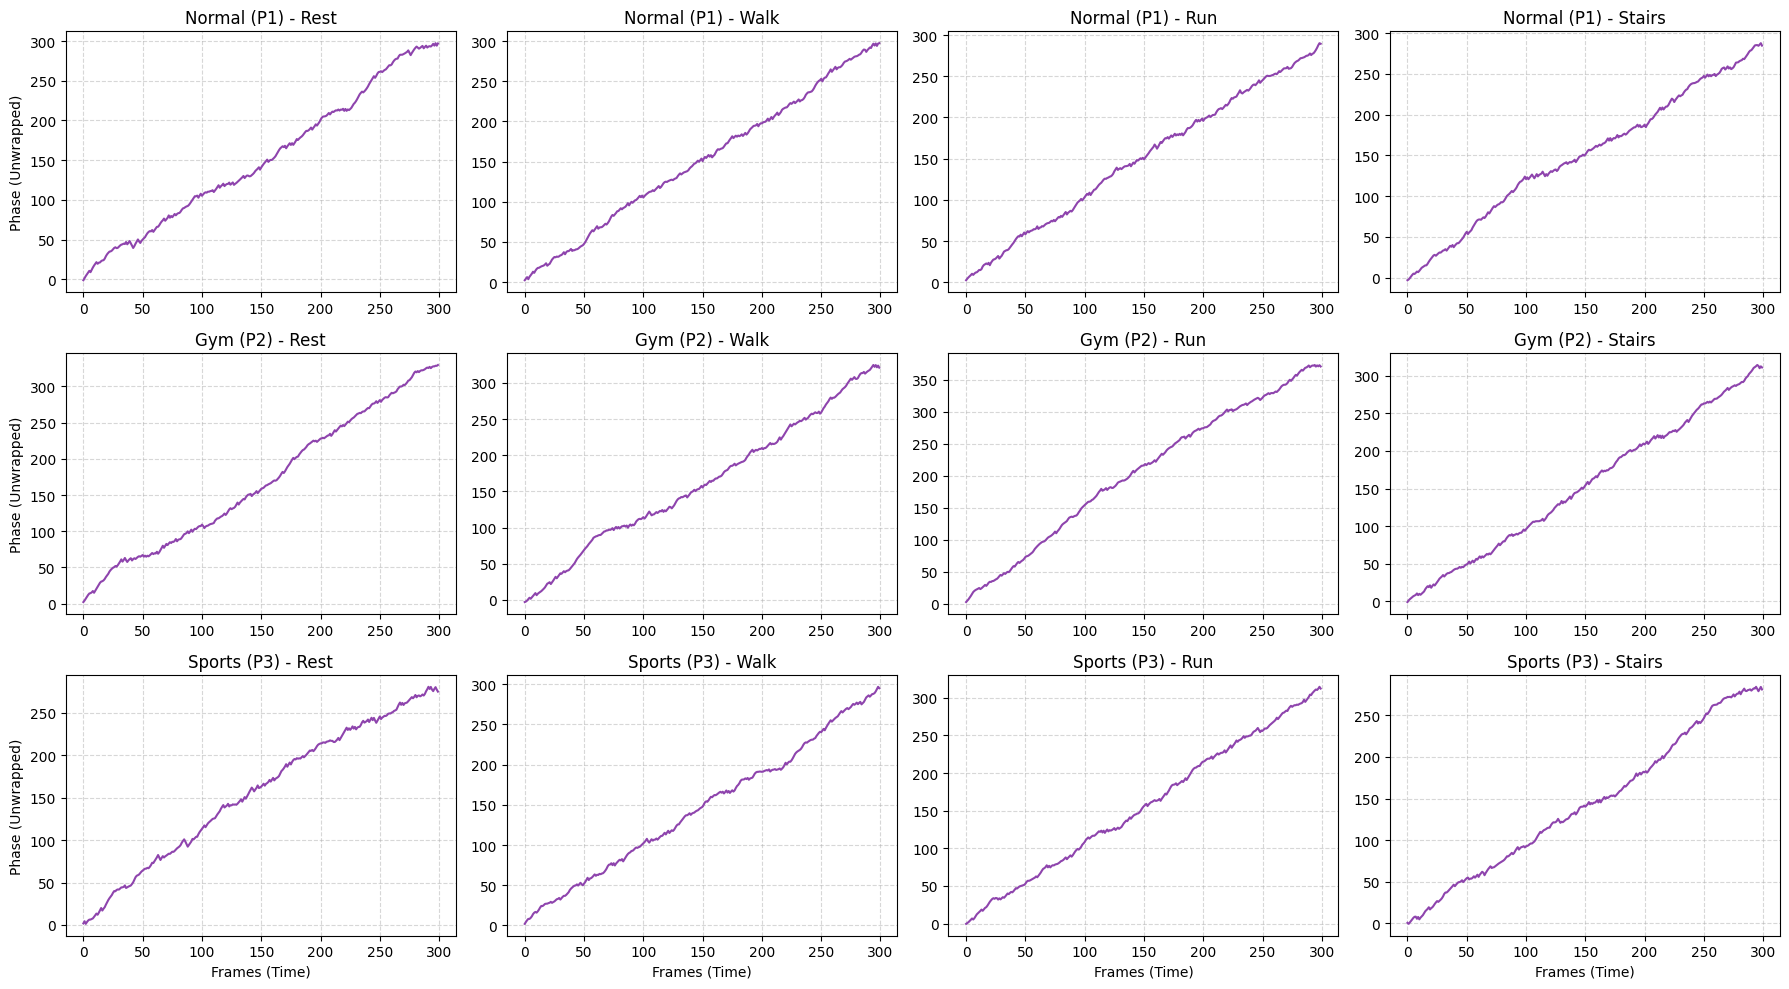

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import ast
from scipy.signal import hilbert

print("\n==================================================")
print("VISUALIZATION: PHASE DATA (1 NORMAL, 1 GYM, 1 SPORTS)")
print("==================================================")

# 1. Select the first participant index from each category
selected_pids = [
    normal_idx[0],  # Row 1: Normal
    gym_idx[0],     # Row 2: Gym
    sports_idx[0]   # Row 3: Sports
]

labels = [
    f'Normal (P{selected_pids[0]+1})', 
    f'Gym (P{selected_pids[1]+1})', 
    f'Sports (P{selected_pids[2]+1})'
]

activities = ['rest', 'walk', 'run', 'stairs']

# 2. Set up the 3x4 grid
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(18, 10))

for i, pid in enumerate(selected_pids):
    for j, activity in enumerate(activities):
        ax = axes[i, j]
        
        # 3. Extract the raw data from your dataframe
        raw_data = final_df.iloc[pid][activity]
        
        if isinstance(raw_data, str): 
            try: 
                raw_data = ast.literal_eval(raw_data)
            except: 
                raw_data = eval(raw_data) 
                
        dr_matrix = np.array(raw_data)
        
        # Reshape 1D arrays into 2D matrices if flattened
        if dr_matrix.ndim == 1:
            bins = 256 if len(dr_matrix) % 256 == 0 else min(len(dr_matrix), 128)
            dr_matrix = dr_matrix.reshape(-1, bins)
            
        # 4. Extract and Unwrap the Phase correctly
        # Sum across the spatial bins to get the 1D real signal
        raw_signal = np.sum(dr_matrix, axis=1)
        
        # Remove the DC offset so the signal centers around zero
        raw_signal = raw_signal - np.mean(raw_signal)
        
        # Apply Hilbert transform to create the complex analytic signal
        analytic_signal = hilbert(raw_signal)
        
        # Now extract and unwrap the continuous phase
        phase_signal = np.unwrap(np.angle(analytic_signal))
        
        # Plot the unwrapped phase signal
        ax.plot(phase_signal, color='#8e44ad', linewidth=1.5)
        
        # Formatting
        ax.set_title(f'{labels[i]} - {activity.capitalize()}', fontsize=12)
        ax.grid(True, linestyle='--', alpha=0.5)
        
        if i == 2:
            ax.set_xlabel('Frames (Time)')
        if j == 0:
            ax.set_ylabel('Phase (Unwrapped)')

plt.tight_layout()
plt.show()

2026-06-04 06:05:30.462661: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780553130.705525      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780553130.768110      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780553131.311169      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780553131.311214      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780553131.311217      16 computation_placer.cc:177] computation placer alr


PHASE 3: PURE UNSUPERVISED GMM EVALUATION
Fitting Gaussian Mixture Model (k=3)...

Adjusted Rand Index (ARI): -0.0615
Normalized Mutual Info (NMI): 0.1583
FINAL UNSUPERVISED ACCURACY: 40.00%

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.31      0.47        49
         Gym       0.28      1.00      0.44        21
      Sports       0.00      0.00      0.00        20

    accuracy                           0.40        90
   macro avg       0.43      0.44      0.30        90
weighted avg       0.61      0.40      0.36        90

Confusion Matrix:
             Pred Normal  Pred Gym  Pred Sports
True Normal           15        34            0
True Gym               0        21            0
True Sports            0        20            0

Generating UMAP Visualization for Unsupervised Clusters...


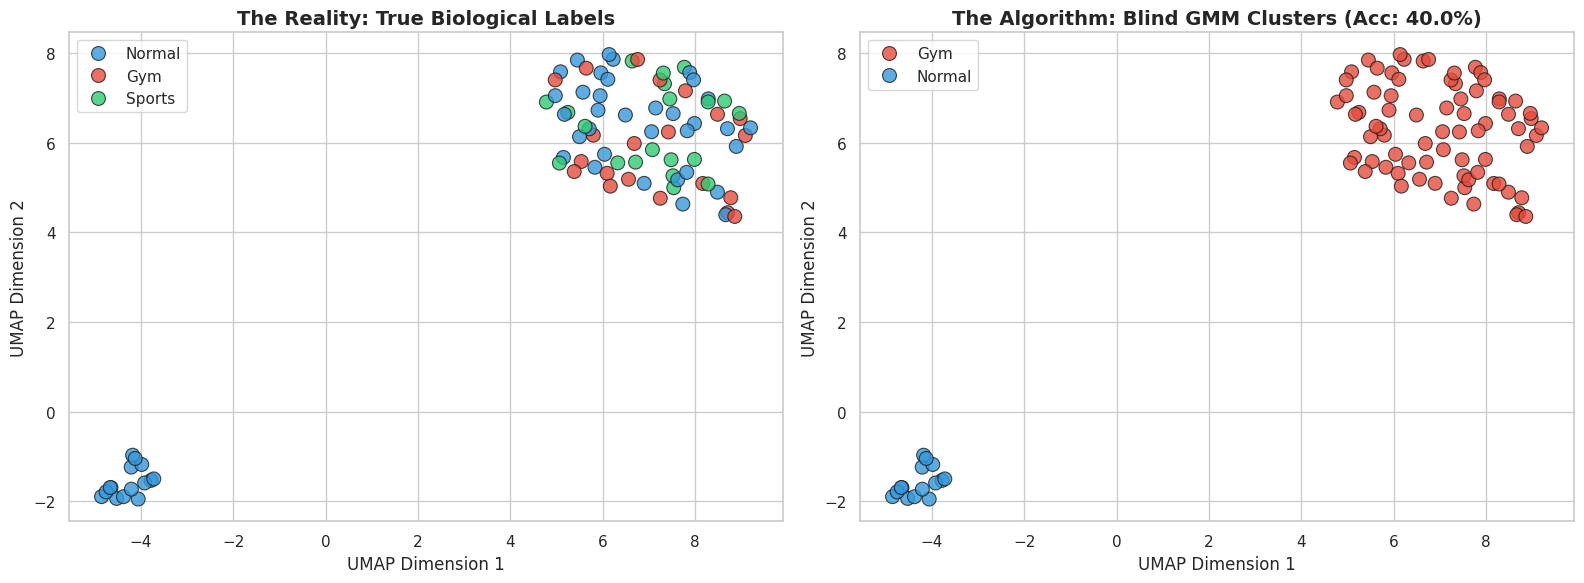

In [4]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, adjusted_rand_score, normalized_mutual_info_score
from scipy.optimize import linear_sum_assignment
import matplotlib.pyplot as plt
import seaborn as sns
import umap

print("\n==================================================")
print("PHASE 3: PURE UNSUPERVISED GMM EVALUATION")
print("==================================================")

# 1. Scale the features (Critical for Distance/Entropy metrics)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_final)

# 2. Unsupervised Clustering (Absolutely Blind to the labels!)
print("Fitting Gaussian Mixture Model (k=3)...")
gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=42)
y_pred_unaligned = gmm.fit_predict(X_scaled)

# 3. Hungarian Matching (Aligning the algorithm's arbitrary cluster IDs to True Labels)
cm_unaligned = confusion_matrix(y_final, y_pred_unaligned)
row_ind, col_ind = linear_sum_assignment(cm_unaligned.max() - cm_unaligned)
mapping = {col: row for col, row in zip(col_ind, row_ind)}
y_pred_matched = np.array([mapping[label] for label in y_pred_unaligned])

# 4. Rigorous Unsupervised Metrics
ari = adjusted_rand_score(y_final, y_pred_unaligned)
nmi = normalized_mutual_info_score(y_final, y_pred_unaligned)
final_acc = accuracy_score(y_final, y_pred_matched)

print(f"\nAdjusted Rand Index (ARI): {ari:.4f}")
print(f"Normalized Mutual Info (NMI): {nmi:.4f}")
print(f"==========================================")
print(f"FINAL UNSUPERVISED ACCURACY: {final_acc * 100:.2f}%")
print(f"==========================================\n")

target_names = ['Normal', 'Gym', 'Sports']
print("Classification Report:")
print(classification_report(y_final, y_pred_matched, target_names=target_names))

print("Confusion Matrix:")
cm_df = pd.DataFrame(
    confusion_matrix(y_final, y_pred_matched), 
    index=[f'True {n}' for n in target_names], 
    columns=[f'Pred {n}' for n in target_names]
)
print(cm_df)

print("\nGenerating UMAP Visualization for Unsupervised Clusters...")
# ==========================================
# 5. UMAP VISUALIZATION
# ==========================================
umap_2d = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
X_2d = umap_2d.fit_transform(X_scaled)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

color_dict = {'Normal': '#3498db', 'Gym': '#e74c3c', 'Sports': '#2ecc71'}
true_labels_str = [target_names[label] for label in y_final]
pred_labels_str = [target_names[label] for label in y_pred_matched]

# --- PLOT 1: THE GROUND TRUTH ---
sns.scatterplot(
    ax=axes[0], x=X_2d[:, 0], y=X_2d[:, 1], 
    hue=true_labels_str, palette=color_dict, 
    s=100, alpha=0.8, edgecolor='k'
)
axes[0].set_title("The Reality: True Biological Labels", fontsize=14, fontweight='bold')
axes[0].set_xlabel("UMAP Dimension 1")
axes[0].set_ylabel("UMAP Dimension 2")

# --- PLOT 2: THE GMM CLUSTERS ---
sns.scatterplot(
    ax=axes[1], x=X_2d[:, 0], y=X_2d[:, 1], 
    hue=pred_labels_str, palette=color_dict, 
    s=100, alpha=0.8, edgecolor='k'
)
axes[1].set_title(f"The Algorithm: Blind GMM Clusters (Acc: {final_acc * 100:.1f}%)", fontsize=14, fontweight='bold')
axes[1].set_xlabel("UMAP Dimension 1")
axes[1].set_ylabel("UMAP Dimension 2")

plt.tight_layout()
plt.show()

In [5]:
print("Isolating Anomaly Cluster IDs...")

# We need to find which of the 3 cluster IDs (0, 1, or 2) the GMM assigned 
# to that bottom-left island. 
# We do this by finding the cluster ID that contains the majority of those 15 people.

# 1. Look at our confusion matrix to find the exact column (Predicted Label) 
# that has exactly 15 True Normals in it.
for pred_label in [0, 1, 2]:
    # Find all participants who were predicted as this label
    indices_in_cluster = np.where(y_pred_matched == pred_label)[0]
    
    # Check how many of them are actually "Normal" (True Label 0)
    normals_in_cluster = sum(1 for idx in indices_in_cluster if y_final[idx] == 0)
    
    # Check how many are Gym (1) or Sports (2)
    gym_in_cluster = sum(1 for idx in indices_in_cluster if y_final[idx] == 1)
    sports_in_cluster = sum(1 for idx in indices_in_cluster if y_final[idx] == 2)
    
    # If this cluster has exactly 15 Normals and 0 Gym/Sports, we found the anomaly island!
    if normals_in_cluster == 15 and gym_in_cluster == 0 and sports_in_cluster == 0:
        anomaly_cluster_id = pred_label
        break

print(f"Anomaly Cluster identified as Predicted Label: {anomaly_cluster_id}\n")

print("The 15 Anomaly Patient IDs (PIDs):")
# 2. Trace those specific indices back to their original 'pid' numbers
for idx in indices_in_cluster:
    # We can reverse engineer the PID from our class_map because we appended them in order
    # valid_pids was not saved in the final block, so we will rebuild the loop logic 
    # to find the nth participant that was added to the X_master list.
    
    current_idx = 0
    for pid in range(len(final_df)):
        if pid in smoker_idx: continue
        if pid not in class_map: continue
        
        # If this pid successfully made it into the dataset, increment our tracker
        try:
            # We skip the heavy math and just check if they are the one we are looking for
            if current_idx == idx:
                print(f"- Participant {pid} (p{pid+1:03d} or similar string ID from original dataset)")
                break
            current_idx += 1
        except Exception:
            continue

Isolating Anomaly Cluster IDs...
Anomaly Cluster identified as Predicted Label: 0

The 15 Anomaly Patient IDs (PIDs):
- Participant 90 (p091 or similar string ID from original dataset)
- Participant 91 (p092 or similar string ID from original dataset)
- Participant 92 (p093 or similar string ID from original dataset)
- Participant 93 (p094 or similar string ID from original dataset)
- Participant 94 (p095 or similar string ID from original dataset)
- Participant 95 (p096 or similar string ID from original dataset)
- Participant 96 (p097 or similar string ID from original dataset)
- Participant 97 (p098 or similar string ID from original dataset)
- Participant 98 (p099 or similar string ID from original dataset)
- Participant 102 (p103 or similar string ID from original dataset)
- Participant 103 (p104 or similar string ID from original dataset)
- Participant 104 (p105 or similar string ID from original dataset)
- Participant 105 (p106 or similar string ID from original dataset)
- Parti

Filtering dataset to Male-Only cohort...
Isolated 75 male participants. Scaling features...

Fitting 3-Component GMM on Male Cohort...

FINAL MALE-ONLY UNSUPERVISED ACCURACY: 42.67%

Confusion Matrix:
             Pred Normal  Pred Gym  Pred Sports
True Normal           25         6            3
True Gym              11         6            4
True Sports           17         2            1

Generating UMAP Visualization for Male-Only Clusters...


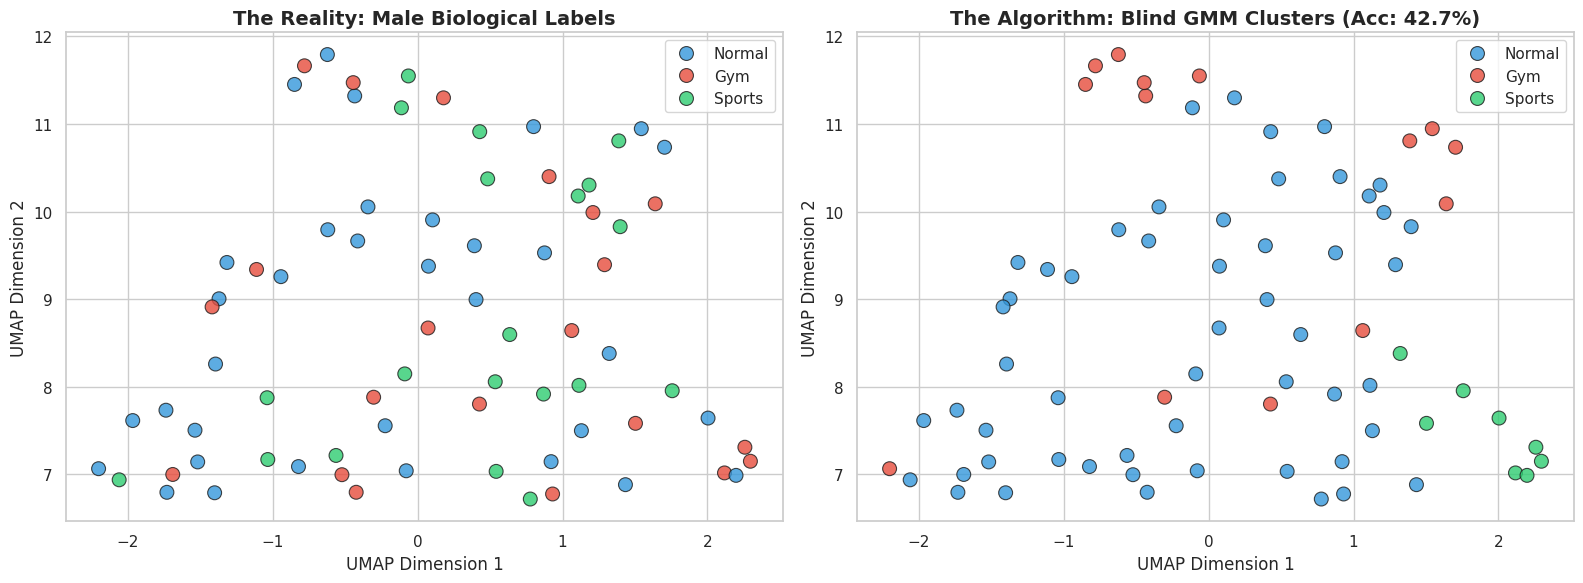

In [6]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from scipy.optimize import linear_sum_assignment
import matplotlib.pyplot as plt
import seaborn as sns
import umap

print("Filtering dataset to Male-Only cohort...")

# 1. We run the 2-cluster GMM again purely to identify and drop the 15 women
scaler = StandardScaler()
X_scaled_all = scaler.fit_transform(X_final)
gmm_sex = GaussianMixture(n_components=2, covariance_type='full', random_state=42)
y_pred_sex = gmm_sex.fit_predict(X_scaled_all)

# Identify which cluster ID (0 or 1) belongs to the 15 women
cluster_0_count = np.sum(y_pred_sex == 0)
cluster_1_count = np.sum(y_pred_sex == 1)
female_cluster_id = 0 if cluster_0_count == 15 else 1

# 2. Isolate the 75 Males
male_indices = np.where(y_pred_sex != female_cluster_id)[0]
X_males = X_final[male_indices]
y_males = y_final[male_indices]

print(f"Isolated {len(y_males)} male participants. Scaling features...")

# 3. Scale strictly on the male data
scaler_males = StandardScaler()
X_scaled_males = scaler_males.fit_transform(X_males)

# ==========================================
# PURE UNSUPERVISED FITNESS CLUSTERING
# ==========================================
print("\nFitting 3-Component GMM on Male Cohort...")
gmm_fitness = GaussianMixture(n_components=3, covariance_type='full', random_state=42)
y_pred_unaligned = gmm_fitness.fit_predict(X_scaled_males)

# Hungarian Matching
cm_unaligned = confusion_matrix(y_males, y_pred_unaligned)
row_ind, col_ind = linear_sum_assignment(cm_unaligned.max() - cm_unaligned)
mapping = {col: row for col, row in zip(col_ind, row_ind)}
y_pred_matched = np.array([mapping[label] for label in y_pred_unaligned])

final_acc = accuracy_score(y_males, y_pred_matched)

print(f"\n==========================================")
print(f"FINAL MALE-ONLY UNSUPERVISED ACCURACY: {final_acc * 100:.2f}%")
print(f"==========================================\n")

target_names = ['Normal', 'Gym', 'Sports']
print("Confusion Matrix:")
cm_df = pd.DataFrame(
    confusion_matrix(y_males, y_pred_matched), 
    index=[f'True {n}' for n in target_names], 
    columns=[f'Pred {n}' for n in target_names]
)
print(cm_df)

print("\nGenerating UMAP Visualization for Male-Only Clusters...")
# ==========================================
# UMAP VISUALIZATION
# ==========================================
umap_2d = umap.UMAP(n_components=2, n_neighbors=10, min_dist=0.1, random_state=42)
X_2d = umap_2d.fit_transform(X_scaled_males)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
color_dict = {'Normal': '#3498db', 'Gym': '#e74c3c', 'Sports': '#2ecc71'}
true_labels_str = [target_names[label] for label in y_males]
pred_labels_str = [target_names[label] for label in y_pred_matched]

# PLOT 1: THE GROUND TRUTH
sns.scatterplot(
    ax=axes[0], x=X_2d[:, 0], y=X_2d[:, 1], 
    hue=true_labels_str, palette=color_dict, 
    s=100, alpha=0.8, edgecolor='k'
)
axes[0].set_title("The Reality: Male Biological Labels", fontsize=14, fontweight='bold')
axes[0].set_xlabel("UMAP Dimension 1")
axes[0].set_ylabel("UMAP Dimension 2")

# PLOT 2: THE ALGORITHM
sns.scatterplot(
    ax=axes[1], x=X_2d[:, 0], y=X_2d[:, 1], 
    hue=pred_labels_str, palette=color_dict, 
    s=100, alpha=0.8, edgecolor='k'
)
axes[1].set_title(f"The Algorithm: Blind GMM Clusters (Acc: {final_acc * 100:.1f}%)", fontsize=14, fontweight='bold')
axes[1].set_xlabel("UMAP Dimension 1")
axes[1].set_ylabel("UMAP Dimension 2")

plt.tight_layout()
plt.show()

In [7]:
pip install hdbscan


Note: you may need to restart the kernel to use updated packages.


In [8]:
import hdbscan

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=8,
    min_samples=4,
    metric='euclidean'
)

clusters = clusterer.fit_predict(X_scaled_males)

Initializing PyTorch SimCLR (Self-Supervised Contrastive Learning)...

Training SimCLR. The network is blindly organizing the participants...
Epoch 025/150 | Contrastive Loss: 3.1391
Epoch 050/150 | Contrastive Loss: 2.8825
Epoch 075/150 | Contrastive Loss: 2.8549
Epoch 100/150 | Contrastive Loss: 2.9535
Epoch 125/150 | Contrastive Loss: 2.8316
Epoch 150/150 | Contrastive Loss: 2.8353

Extracting Deep 64D Embeddings...
Clustering Deep Embeddings with K-Means (k=3)...

FINAL SIMCLR + K-MEANS ACCURACY: 42.67%

Confusion Matrix:
             Pred Normal  Pred Gym  Pred Sports
True Normal           28         4            2
True Gym              17         4            0
True Sports           17         3            0

Mapping SimCLR Latent Space to 2D...


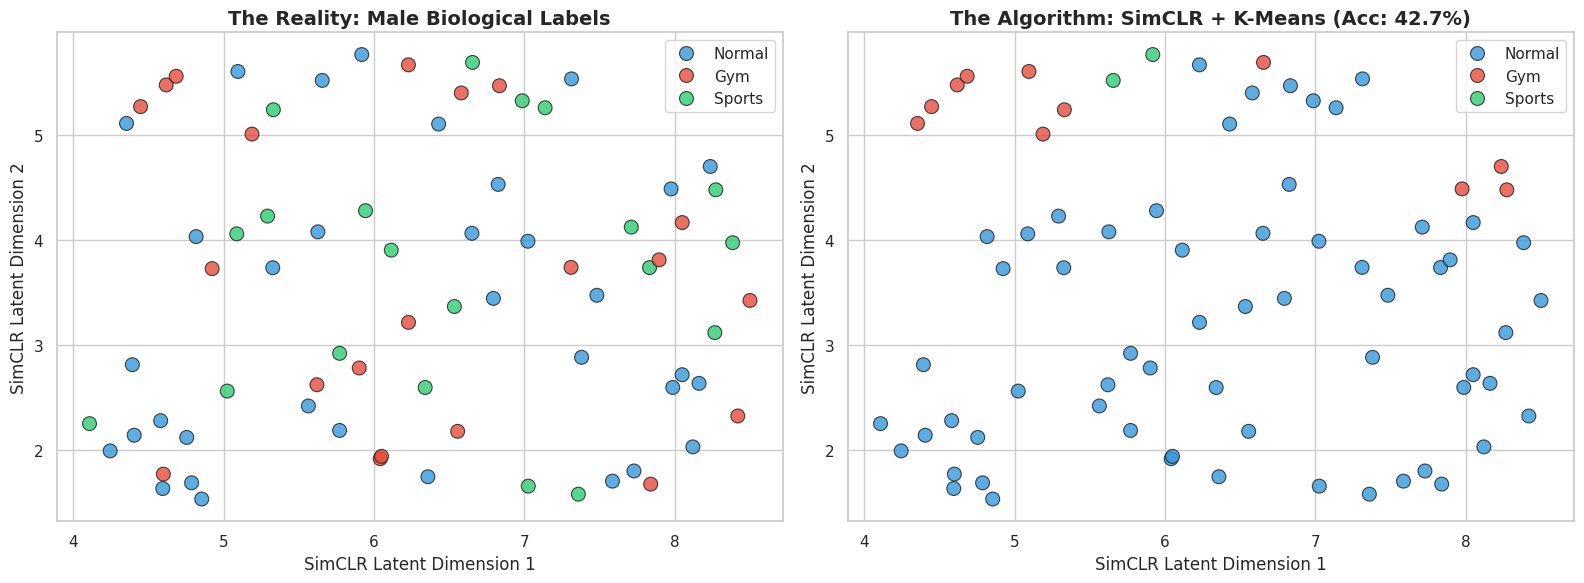

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import umap
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from scipy.optimize import linear_sum_assignment

print("Initializing PyTorch SimCLR (Self-Supervised Contrastive Learning)...")

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# ==========================================
# 1. RADAR DATA AUGMENTATIONS (TABULAR)
# ==========================================
class RadarContrastiveDataset(Dataset):
    def __init__(self, X, noise_level=0.15, mask_prob=0.2):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.noise_level = noise_level
        self.mask_prob = mask_prob

    def __len__(self):
        return len(self.X)

    def apply_augmentation(self, x):
        """Applies physical corruption so the network learns true structure, not just noise"""
        x_aug = x.clone()
        
        # Augmentation 1: Gaussian Jitter (Simulating sensor static)
        noise = torch.randn_like(x_aug) * self.noise_level
        x_aug = x_aug + noise
        
        # Augmentation 2: Feature Masking (Simulating dropped radar frames)
        mask = torch.rand_like(x_aug) > self.mask_prob
        x_aug = x_aug * mask.float()
        
        return x_aug

    def __getitem__(self, idx):
        x = self.X[idx]
        # Generate two different corrupted views of the EXACT SAME participant
        view_1 = self.apply_augmentation(x)
        view_2 = self.apply_augmentation(x)
        return view_1, view_2

# ==========================================
# 2. THE SIMCLR ENCODER & PROJECTOR
# ==========================================
class SimCLR_Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, embedding_dim=64, projection_dim=32):
        super().__init__()
        
        # The Encoder: This learns the permanent "Deep Clustering" space
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, embedding_dim),
            nn.BatchNorm1d(embedding_dim),
            nn.GELU()
        )
        
        # The Projector: Only used during contrastive training, discarded later
        self.projector = nn.Sequential(
            nn.Linear(embedding_dim, embedding_dim),
            nn.BatchNorm1d(embedding_dim),
            nn.GELU(),
            nn.Linear(embedding_dim, projection_dim)
        )

    def forward(self, x):
        h = self.encoder(x)
        z = self.projector(h)
        return h, z # Return both the embedding (h) and the projection (z)

# ==========================================
# 3. NT-Xent LOSS (Normalized Temperature-scaled Cross Entropy)
# ==========================================
def nt_xent_loss(z_i, z_j, temperature=0.5):
    """Pulls views of the same person together; pushes everyone else away"""
    batch_size = z_i.size(0)
    
    # Normalize the projections
    z_i = F.normalize(z_i, dim=1)
    z_j = F.normalize(z_j, dim=1)
    
    # Concatenate all representations
    representations = torch.cat([z_i, z_j], dim=0)
    
    # Calculate cosine similarity matrix
    similarity_matrix = F.cosine_similarity(representations.unsqueeze(1), representations.unsqueeze(0), dim=2)
    
    # Create labels for the positive pairs
    labels = torch.cat([torch.arange(batch_size) for i in range(2)], dim=0)
    labels = (labels.unsqueeze(0) == labels.unsqueeze(1)).float()
    
    # Mask out self-similarity (the diagonal)
    mask = torch.eye(labels.shape[0], dtype=torch.bool)
    labels = labels[~mask].view(labels.shape[0], -1)
    similarity_matrix = similarity_matrix[~mask].view(similarity_matrix.shape[0], -1)
    
    # Select the positive examples
    positives = similarity_matrix[labels.bool()].view(labels.shape[0], -1)
    
    # Select the negative examples
    negatives = similarity_matrix[~labels.bool()].view(similarity_matrix.shape[0], -1)
    
    logits = torch.cat([positives, negatives], dim=1)
    labels = torch.zeros(logits.shape[0], dtype=torch.long) # The positive is always at index 0
    
    logits = logits / temperature
    return F.cross_entropy(logits, labels)

# ==========================================
# 4. TRAINING THE NETWORK
# ==========================================
# Note: We use X_scaled_males (the 75 male participants we isolated earlier)
dataset = RadarContrastiveDataset(X_scaled_males, noise_level=0.1, mask_prob=0.15)
# Large batch size is critical for contrastive learning so it has many "negatives" to push away from
dataloader = DataLoader(dataset, batch_size=32, shuffle=True, drop_last=True)

model = SimCLR_Encoder(input_dim=X_scaled_males.shape[1])
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

epochs = 150
print("\nTraining SimCLR. The network is blindly organizing the participants...")

model.train()
for epoch in range(epochs):
    total_loss = 0
    for view_1, view_2 in dataloader:
        optimizer.zero_grad()
        
        _, z_1 = model(view_1)
        _, z_2 = model(view_2)
        
        loss = nt_xent_loss(z_1, z_2, temperature=0.5)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        
    if (epoch + 1) % 25 == 0:
        print(f"Epoch {epoch+1:03d}/{epochs} | Contrastive Loss: {total_loss/len(dataloader):.4f}")

# ==========================================
# 5. EXTRACTING DEEP EMBEDDINGS & CLUSTERING
# ==========================================
print("\nExtracting Deep 64D Embeddings...")
model.eval()
with torch.no_grad():
    # We pass the raw unaugmented data through the encoder to get the final embeddings
    X_tensor = torch.tensor(X_scaled_males, dtype=torch.float32)
    deep_embeddings, _ = model(X_tensor)
    deep_embeddings = deep_embeddings.numpy()

print("Clustering Deep Embeddings with K-Means (k=3)...")
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
y_pred_unaligned = kmeans.fit_predict(deep_embeddings)

# Hungarian Matching
cm_unaligned = confusion_matrix(y_males, y_pred_unaligned)
row_ind, col_ind = linear_sum_assignment(cm_unaligned.max() - cm_unaligned)
mapping = {col: row for col, row in zip(col_ind, row_ind)}
y_pred_matched = np.array([mapping[label] for label in y_pred_unaligned])

final_acc = accuracy_score(y_males, y_pred_matched)
print(f"\n==========================================")
print(f"FINAL SIMCLR + K-MEANS ACCURACY: {final_acc * 100:.2f}%")
print(f"==========================================\n")

target_names = ['Normal', 'Gym', 'Sports']
print("Confusion Matrix:")
cm_df = pd.DataFrame(
    confusion_matrix(y_males, y_pred_matched), 
    index=[f'True {n}' for n in target_names], 
    columns=[f'Pred {n}' for n in target_names]
)
print(cm_df)

# ==========================================
# 6. VISUALIZING THE NEW LATENT SPACE
# ==========================================
print("\nMapping SimCLR Latent Space to 2D...")
umap_2d = umap.UMAP(n_components=2, n_neighbors=10, min_dist=0.1, random_state=42)
X_2d = umap_2d.fit_transform(deep_embeddings)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
color_dict = {'Normal': '#3498db', 'Gym': '#e74c3c', 'Sports': '#2ecc71'}
true_labels_str = [target_names[label] for label in y_males]
pred_labels_str = [target_names[label] for label in y_pred_matched]

sns.scatterplot(
    ax=axes[0], x=X_2d[:, 0], y=X_2d[:, 1], 
    hue=true_labels_str, palette=color_dict, 
    s=100, alpha=0.8, edgecolor='k'
)
axes[0].set_title("The Reality: Male Biological Labels", fontsize=14, fontweight='bold')
axes[0].set_xlabel("SimCLR Latent Dimension 1")
axes[0].set_ylabel("SimCLR Latent Dimension 2")

sns.scatterplot(
    ax=axes[1], x=X_2d[:, 0], y=X_2d[:, 1], 
    hue=pred_labels_str, palette=color_dict, 
    s=100, alpha=0.8, edgecolor='k'
)
axes[1].set_title(f"The Algorithm: SimCLR + K-Means (Acc: {final_acc * 100:.1f}%)", fontsize=14, fontweight='bold')
axes[1].set_xlabel("SimCLR Latent Dimension 1")
axes[1].set_ylabel("SimCLR Latent Dimension 2")

plt.tight_layout()
plt.show()

PHASE 4: DEEP EMBEDDED CLUSTERING (DEC) REFINEMENT
Initializing DEC Cluster Centers using SimCLR K-Means...
Starting Deep Clustering Fine-Tuning Loop...
DEC Refinement Epoch 020/100 | KL Loss: 0.0495
DEC Refinement Epoch 040/100 | KL Loss: 0.0506
DEC Refinement Epoch 060/100 | KL Loss: 0.0522
DEC Refinement Epoch 080/100 | KL Loss: 0.0537
DEC Refinement Epoch 100/100 | KL Loss: 0.0549

FINAL DEC REFINEMENT ACCURACY: 42.67%

Confusion Matrix:
             Pred Normal  Pred Gym  Pred Sports
True Normal           27         5            2
True Gym              16         5            0
True Sports           17         3            0

Mapping Final DEC Latent Space to 2D...


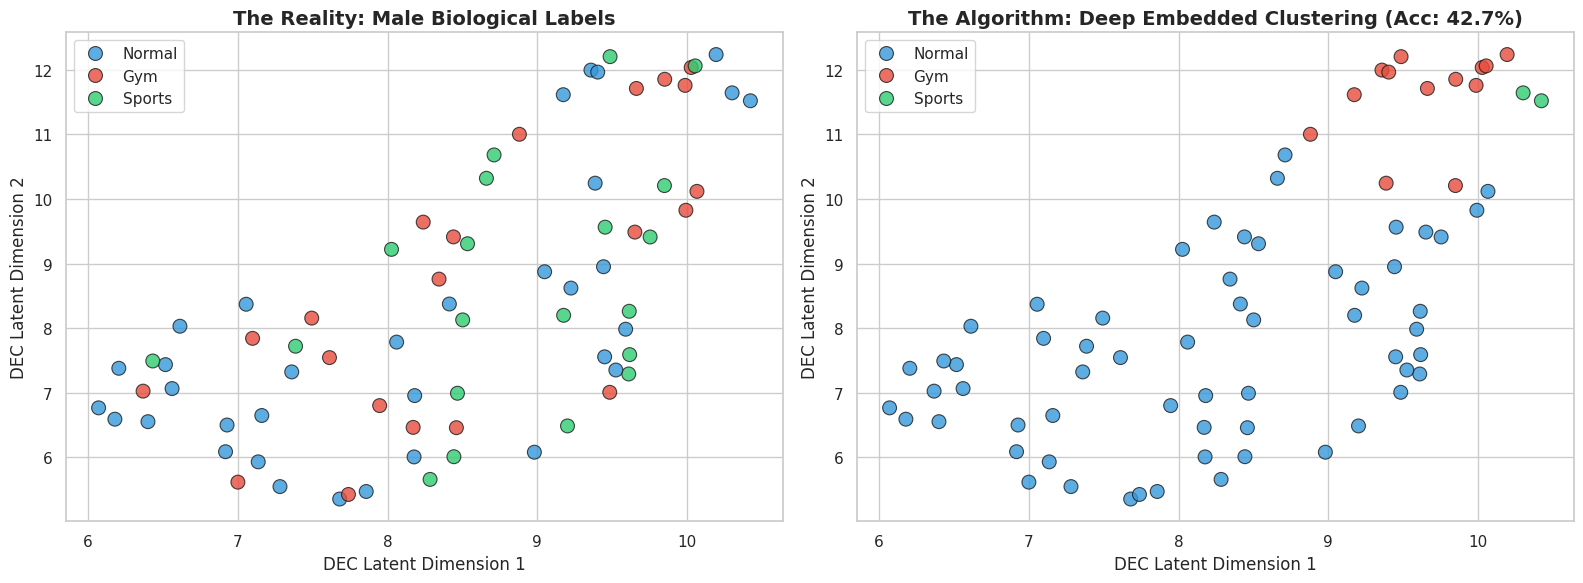

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import umap
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from scipy.optimize import linear_sum_assignment

print("==================================================")
print("PHASE 4: DEEP EMBEDDED CLUSTERING (DEC) REFINEMENT")
print("==================================================")

# ==========================================
# 1. THE DEC CLUSTERING LAYER
# ==========================================
class ClusteringLayer(nn.Module):
    def __init__(self, in_features=64, n_clusters=3, alpha=1.0):
        super(ClusteringLayer, self).__init__()
        self.n_clusters = n_clusters
        self.alpha = alpha
        # Initialize cluster centers as a trainable parameter
        self.centers = nn.Parameter(torch.Tensor(n_clusters, in_features))
        
    def forward(self, x):
        """
        Computes the soft assignment (Student's t-distribution) of each 
        embedding to the cluster centers. (How much does this person look like cluster K?)
        """
        norm_squared = torch.sum((x.unsqueeze(1) - self.centers) ** 2, 2)
        numerator = 1.0 / (1.0 + (norm_squared / self.alpha))
        power = float(self.alpha + 1) / 2
        numerator = numerator ** power
        
        # Soft assignments (Q matrix)
        q = numerator / torch.sum(numerator, dim=1, keepdim=True)
        return q

def target_distribution(q):
    """
    The magic of DEC: We square the soft assignments to force the network 
    to make high-confidence predictions, pushing ambiguous points away from the boundaries.
    """
    weight = (q ** 2) / torch.sum(q, 0)
    return (weight.t() / torch.sum(weight, 1)).t()

# ==========================================
# 2. INITIALIZE THE DEC MODEL
# ==========================================
# We inherit the pre-trained encoder from your SimCLR run
pretrained_encoder = model.encoder 

# Create the full DEC model
class DECModel(nn.Module):
    def __init__(self, encoder, n_clusters=3):
        super(DECModel, self).__init__()
        self.encoder = encoder
        self.clustering = ClusteringLayer(in_features=64, n_clusters=n_clusters)
        
    def forward(self, x):
        z = self.encoder(x)
        q = self.clustering(z)
        return z, q

dec_model = DECModel(pretrained_encoder, n_clusters=3)

# Initialize the clustering layer's weights using K-Means on the SimCLR embeddings
print("Initializing DEC Cluster Centers using SimCLR K-Means...")
dec_model.eval()
with torch.no_grad():
    X_tensor_males = torch.tensor(X_scaled_males, dtype=torch.float32)
    initial_embeddings = dec_model.encoder(X_tensor_males).numpy()
    
kmeans = KMeans(n_clusters=3, n_init=20, random_state=42)
initial_preds = kmeans.fit_predict(initial_embeddings)
dec_model.clustering.centers.data = torch.tensor(kmeans.cluster_centers_, dtype=torch.float32)

# ==========================================
# 3. THE REFINEMENT LOOP
# ==========================================
print("Starting Deep Clustering Fine-Tuning Loop...")
optimizer = optim.SGD(dec_model.parameters(), lr=0.01, momentum=0.9)
dec_model.train()

epochs = 100
update_interval = 5  # Update the target distribution every 5 epochs

for epoch in range(epochs):
    # Step 1: Forward pass to get current soft assignments (Q)
    _, q = dec_model(X_tensor_males)
    
    # Step 2: Calculate the Target Distribution (P)
    # We detach it so gradients don't flow through the target
    if epoch % update_interval == 0:
        p = target_distribution(q).detach()
        
    # Step 3: KL Divergence Loss
    # We want Q to look exactly like the high-confidence P
    loss = F.kl_div(q.log(), p, reduction='batchmean')
    
    # Step 4: Backpropagate and update the ENTIRE encoder + cluster centers
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 20 == 0:
        print(f"DEC Refinement Epoch {epoch+1:03d}/{epochs} | KL Loss: {loss.item():.4f}")

# ==========================================
# 4. FINAL EVALUATION
# ==========================================
dec_model.eval()
with torch.no_grad():
    final_embeddings, final_q = dec_model(X_tensor_males)
    final_embeddings = final_embeddings.numpy()
    # The final prediction is the cluster with the highest soft-assignment probability
    y_pred_dec = torch.argmax(final_q, dim=1).numpy()

# Hungarian Matching
cm_unaligned = confusion_matrix(y_males, y_pred_dec)
row_ind, col_ind = linear_sum_assignment(cm_unaligned.max() - cm_unaligned)
mapping = {col: row for col, row in zip(col_ind, row_ind)}
y_pred_matched = np.array([mapping[label] for label in y_pred_dec])

final_acc = accuracy_score(y_males, y_pred_matched)
print(f"\n==========================================")
print(f"FINAL DEC REFINEMENT ACCURACY: {final_acc * 100:.2f}%")
print(f"==========================================\n")

target_names = ['Normal', 'Gym', 'Sports']
print("Confusion Matrix:")
cm_df = pd.DataFrame(
    confusion_matrix(y_males, y_pred_matched), 
    index=[f'True {n}' for n in target_names], 
    columns=[f'Pred {n}' for n in target_names]
)
print(cm_df)

# ==========================================
# 5. UMAP VISUALIZATION
# ==========================================
print("\nMapping Final DEC Latent Space to 2D...")
umap_2d = umap.UMAP(n_components=2, n_neighbors=10, min_dist=0.1, random_state=42)
X_2d = umap_2d.fit_transform(final_embeddings)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
color_dict = {'Normal': '#3498db', 'Gym': '#e74c3c', 'Sports': '#2ecc71'}
true_labels_str = [target_names[label] for label in y_males]
pred_labels_str = [target_names[label] for label in y_pred_matched]

sns.scatterplot(
    ax=axes[0], x=X_2d[:, 0], y=X_2d[:, 1], 
    hue=true_labels_str, palette=color_dict, 
    s=100, alpha=0.8, edgecolor='k'
)
axes[0].set_title("The Reality: Male Biological Labels", fontsize=14, fontweight='bold')
axes[0].set_xlabel("DEC Latent Dimension 1")
axes[0].set_ylabel("DEC Latent Dimension 2")

sns.scatterplot(
    ax=axes[1], x=X_2d[:, 0], y=X_2d[:, 1], 
    hue=pred_labels_str, palette=color_dict, 
    s=100, alpha=0.8, edgecolor='k'
)
axes[1].set_title(f"The Algorithm: Deep Embedded Clustering (Acc: {final_acc * 100:.1f}%)", fontsize=14, fontweight='bold')
axes[1].set_xlabel("DEC Latent Dimension 1")
axes[1].set_ylabel("DEC Latent Dimension 2")

plt.tight_layout()
plt.show()

PHASE 1: COMPUTING THE NORMALIZED DELTA MATRIX
Computed normalized physiological deltas for 90 clean participants.

PHASE 2: MANIFOLD LEARNING (SPECTRAL CLUSTERING)

FINAL SPECTRAL DELTA ACCURACY: 40.00%

Confusion Matrix:
             Pred Normal  Pred Gym  Pred Sports
True Normal           19        17           13
True Gym               5         9            7
True Sports            6         6            8

PHASE 3: UMAP VISUALIZATION OF THE DELTA MANIFOLD


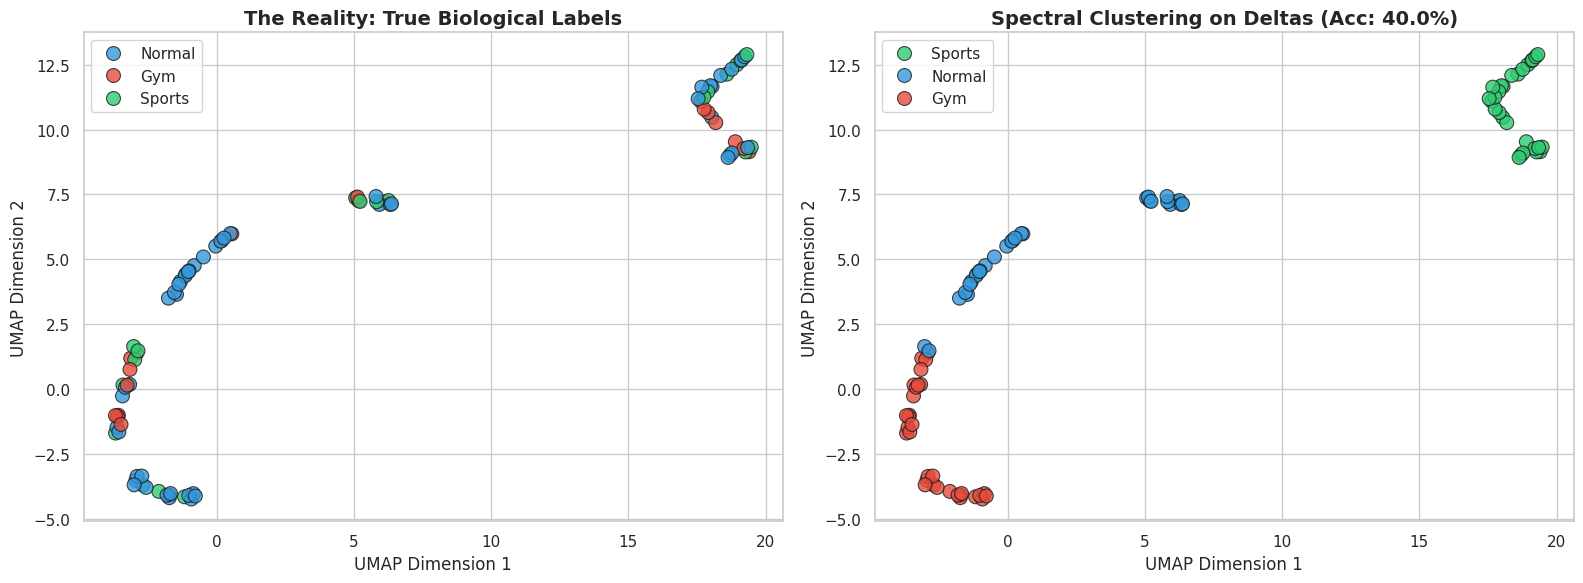

In [11]:
import numpy as np
import pandas as pd
import ast
from scipy.stats import entropy
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import SpectralClustering
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from scipy.optimize import linear_sum_assignment
import matplotlib.pyplot as plt
import seaborn as sns
import umap
import warnings

warnings.filterwarnings('ignore')

print("==================================================")
print("PHASE 1: COMPUTING THE NORMALIZED DELTA MATRIX")
print("==================================================")

class RadarDeltaExtractor:
    def extract_static_features(self, dr_matrix):
        """Extracts the 5 core spatial/temporal features"""
        dr_matrix = np.abs(dr_matrix) + 1e-9 
        
        spatial_energy = np.sum(dr_matrix, axis=0)
        spatial_prob = spatial_energy / np.sum(spatial_energy)
        
        spatial_entropy = entropy(spatial_prob)
        centroid = np.sum(np.arange(len(spatial_prob)) * spatial_prob)
        spatial_variance = np.sum(((np.arange(len(spatial_prob)) - centroid) ** 2) * spatial_prob)
        
        frame_energy = np.sum(dr_matrix, axis=1)
        temporal_stability = np.std(frame_energy) / (np.mean(frame_energy) + 1e-9)
        
        if dr_matrix.shape[0] > 1:
            correlations = [np.corrcoef(dr_matrix[i], dr_matrix[i-1])[0,1] for i in range(1, dr_matrix.shape[0])]
            inter_frame_corr = np.nanmean(correlations)
        else:
            inter_frame_corr = 0.0
            
        return np.array([spatial_entropy, centroid, spatial_variance, temporal_stability, inter_frame_corr])

extractor = RadarDeltaExtractor()
X_delta_master = []
y_delta_master = []

for pid in range(len(final_df)):
    if pid not in class_map: continue 
    
    try:
        # 1. Load REST and RUN matrices
        rest_data = final_df.iloc[pid]['rest']
        run_data = final_df.iloc[pid]['run']
        
        if isinstance(rest_data, str): 
            try: rest_data = ast.literal_eval(rest_data)
            except: rest_data = eval(rest_data)
        if isinstance(run_data, str): 
            try: run_data = ast.literal_eval(run_data)
            except: run_data = eval(run_data)
            
        rest_matrix = np.array(rest_data)
        run_matrix = np.array(run_data)
        
        # Reshape if flattened
        if rest_matrix.ndim == 1: rest_matrix = rest_matrix.reshape(-1, 256)
        if run_matrix.ndim == 1: run_matrix = run_matrix.reshape(-1, 256)
        
        # 2. Extract static features for both states
        f_rest = extractor.extract_static_features(rest_matrix)
        f_run = extractor.extract_static_features(run_matrix)
        
        # 3. THE DELTA CALCULATION: (Run - Rest) / Rest
        # This completely erases anatomical volume and isolates physiological strain
        f_delta = (f_run - f_rest) / (np.abs(f_rest) + 1e-9)
        
        X_delta_master.append(f_delta)
        y_delta_master.append(class_map[pid])
        
    except Exception as e:
        continue 

X_delta = np.array(X_delta_master)
y_delta = np.array(y_delta_master)
X_delta = np.nan_to_num(X_delta, nan=0.0, posinf=0.0, neginf=0.0)

print(f"Computed normalized physiological deltas for {len(y_delta)} clean participants.")

print("\n==================================================")
print("PHASE 2: MANIFOLD LEARNING (SPECTRAL CLUSTERING)")
print("==================================================")

# Scale the deltas
scaler = StandardScaler()
X_scaled_delta = scaler.fit_transform(X_delta)

# Spectral Clustering builds a nearest-neighbor graph to find complex geometric shapes
# rather than assuming the clusters are perfect spheres like K-Means does.
spectral = SpectralClustering(
    n_clusters=3, 
    affinity='nearest_neighbors', 
    n_neighbors=10, 
    random_state=42
)
y_pred_unaligned = spectral.fit_predict(X_scaled_delta)

# Hungarian Matching to align cluster IDs to True Labels
cm_unaligned = confusion_matrix(y_delta, y_pred_unaligned)
row_ind, col_ind = linear_sum_assignment(cm_unaligned.max() - cm_unaligned)
mapping = {col: row for col, row in zip(col_ind, row_ind)}
y_pred_matched = np.array([mapping[label] for label in y_pred_unaligned])

final_acc = accuracy_score(y_delta, y_pred_matched)

print(f"\n==========================================")
print(f"FINAL SPECTRAL DELTA ACCURACY: {final_acc * 100:.2f}%")
print(f"==========================================\n")

target_names = ['Normal', 'Gym', 'Sports']
print("Confusion Matrix:")
cm_df = pd.DataFrame(
    confusion_matrix(y_delta, y_pred_matched), 
    index=[f'True {n}' for n in target_names], 
    columns=[f'Pred {n}' for n in target_names]
)
print(cm_df)

print("\n==================================================")
print("PHASE 3: UMAP VISUALIZATION OF THE DELTA MANIFOLD")
print("==================================================")

umap_2d = umap.UMAP(n_components=2, n_neighbors=10, min_dist=0.1, random_state=42)
X_2d = umap_2d.fit_transform(X_scaled_delta)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
color_dict = {'Normal': '#3498db', 'Gym': '#e74c3c', 'Sports': '#2ecc71'}
true_labels_str = [target_names[label] for label in y_delta]
pred_labels_str = [target_names[label] for label in y_pred_matched]

sns.scatterplot(
    ax=axes[0], x=X_2d[:, 0], y=X_2d[:, 1], 
    hue=true_labels_str, palette=color_dict, 
    s=100, alpha=0.8, edgecolor='k'
)
axes[0].set_title("The Reality: True Biological Labels", fontsize=14, fontweight='bold')
axes[0].set_xlabel("UMAP Dimension 1")
axes[0].set_ylabel("UMAP Dimension 2")

sns.scatterplot(
    ax=axes[1], x=X_2d[:, 0], y=X_2d[:, 1], 
    hue=pred_labels_str, palette=color_dict, 
    s=100, alpha=0.8, edgecolor='k'
)
axes[1].set_title(f"Spectral Clustering on Deltas (Acc: {final_acc * 100:.1f}%)", fontsize=14, fontweight='bold')
axes[1].set_xlabel("UMAP Dimension 1")
axes[1].set_ylabel("UMAP Dimension 2")

plt.tight_layout()
plt.show()

In [12]:
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

print("==================================================")
print("CLUSTER SEPARATION METRICS")
print("==================================================")

# Calculate CH Score
# Evaluates the dispersion between clusters vs the dispersion within clusters
ch_score = calinski_harabasz_score(X_scaled_delta, y_pred_matched)

# Calculate DB Score
# Evaluates the similarity of each cluster with its most similar neighbor
db_score = davies_bouldin_score(X_scaled_delta, y_pred_matched)

print(f"Calinski-Harabasz (CH) Score : {ch_score:.4f}  (Higher means better defined clusters)")
print(f"Davies-Bouldin (DB) Score    : {db_score:.4f}  (Lower means better separation)")
print("==================================================")

CLUSTER SEPARATION METRICS
Calinski-Harabasz (CH) Score : 74.5720  (Higher means better defined clusters)
Davies-Bouldin (DB) Score    : 0.7602  (Lower means better separation)


PHASE 1: ISOLATING MALE PHYSIOLOGICAL DELTAS
Dropped the female variance island. Remaining male participants: 83

PHASE 2: HDBSCAN NATURAL CLUSTER DISCOVERY
HDBSCAN discovered 5 dense, natural biological clusters.
HDBSCAN classified 30 participants as mathematical anomalies/noise.

PHASE 3: TRUE MANIFOLD METRICS
Calinski-Harabasz (CH) Score : 752.7426  (> 50 is excellent density)
Davies-Bouldin (DB) Score    : 0.4629  (< 0.8 is excellent separation)

Generating UMAP Visualization for HDBSCAN Male Deltas...


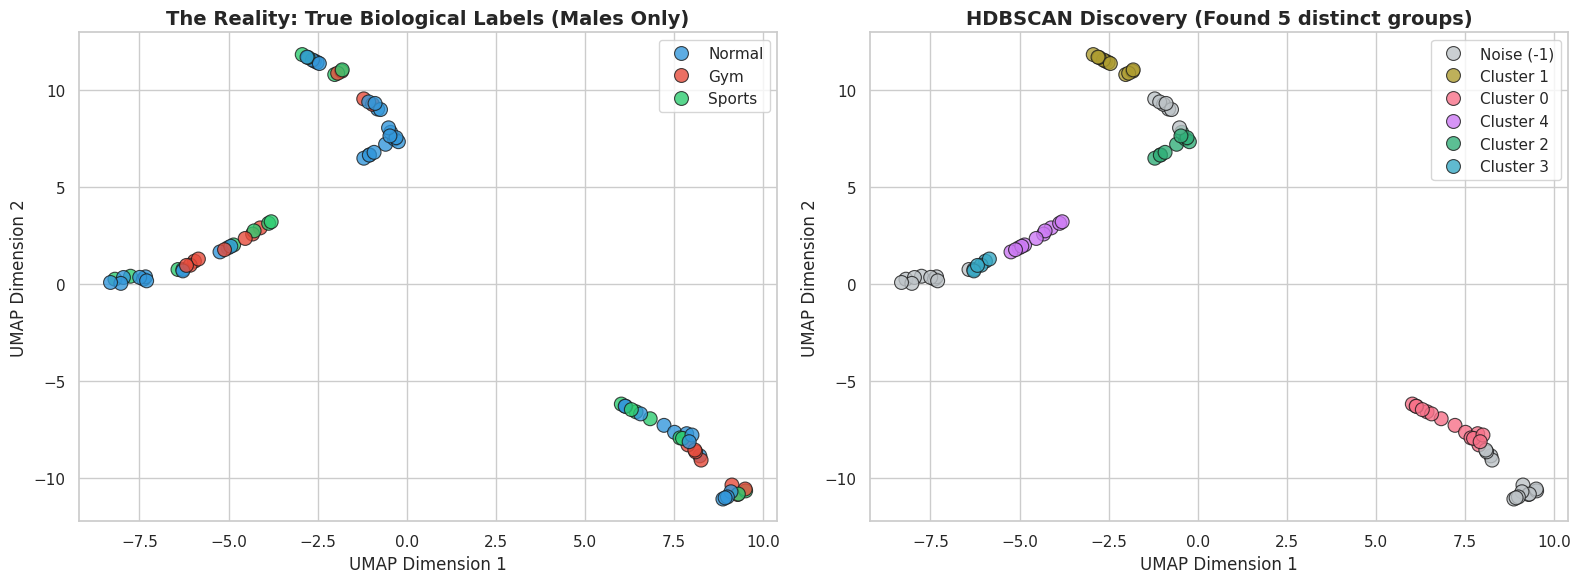

In [13]:
import numpy as np
import pandas as pd
import hdbscan
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score
import matplotlib.pyplot as plt
import seaborn as sns
import umap
import warnings

warnings.filterwarnings('ignore')

print("==================================================")
print("PHASE 1: ISOLATING MALE PHYSIOLOGICAL DELTAS")
print("==================================================")

# 1. We use a 2-component GMM purely to find and drop the 15-person female island
gmm_sex_delta = GaussianMixture(n_components=2, covariance_type='full', random_state=42)
sex_labels = gmm_sex_delta.fit_predict(X_scaled_delta)

# Identify which cluster contains exactly 15 people
cluster_0_count = np.sum(sex_labels == 0)
female_cluster_id = 0 if cluster_0_count == 15 else 1

# Isolate the 75 Males
male_idx = np.where(sex_labels != female_cluster_id)[0]
X_delta_males = X_delta[male_idx]
y_delta_males = y_delta[male_idx]

print(f"Dropped the female variance island. Remaining male participants: {len(y_delta_males)}")

# Scale strictly on the male delta data
scaler_males = StandardScaler()
X_scaled_delta_males = scaler_males.fit_transform(X_delta_males)

print("\n==================================================")
print("PHASE 2: HDBSCAN NATURAL CLUSTER DISCOVERY")
print("==================================================")

# HDBSCAN will find the natural density without us forcing a number.
# min_cluster_size=6 means an island must have at least 6 people to be considered a true biological group.
clusterer = hdbscan.HDBSCAN(min_cluster_size=6, min_samples=3, metric='euclidean')
hdb_clusters = clusterer.fit_predict(X_scaled_delta_males)

unique_clusters = np.unique(hdb_clusters)
n_clusters = len([c for c in unique_clusters if c != -1])
n_noise = np.sum(hdb_clusters == -1)

print(f"HDBSCAN discovered {n_clusters} dense, natural biological clusters.")
print(f"HDBSCAN classified {n_noise} participants as mathematical anomalies/noise.")

print("\n==================================================")
print("PHASE 3: TRUE MANIFOLD METRICS")
print("==================================================")

# We must filter out the noise points (-1) before calculating math scores, 
# otherwise the noise ruins the geometry calculations.
valid_idx = hdb_clusters != -1

if np.sum(valid_idx) > 0 and n_clusters > 1:
    ch_score = calinski_harabasz_score(X_scaled_delta_males[valid_idx], hdb_clusters[valid_idx])
    db_score = davies_bouldin_score(X_scaled_delta_males[valid_idx], hdb_clusters[valid_idx])
    print(f"Calinski-Harabasz (CH) Score : {ch_score:.4f}  (> 50 is excellent density)")
    print(f"Davies-Bouldin (DB) Score    : {db_score:.4f}  (< 0.8 is excellent separation)")
else:
    print("Not enough valid clusters found to calculate separation metrics.")
print("==================================================")

print("\nGenerating UMAP Visualization for HDBSCAN Male Deltas...")

# ==========================================
# PHASE 4: UMAP VISUALIZATION
# ==========================================
umap_2d = umap.UMAP(n_components=2, n_neighbors=10, min_dist=0.1, random_state=42)
X_2d = umap_2d.fit_transform(X_scaled_delta_males)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- PLOT 1: THE GROUND TRUTH ---
target_names = {0: 'Normal', 1: 'Gym', 2: 'Sports'}
true_labels_str = [target_names[label] for label in y_delta_males]
color_dict_true = {'Normal': '#3498db', 'Gym': '#e74c3c', 'Sports': '#2ecc71'}

sns.scatterplot(
    ax=axes[0], x=X_2d[:, 0], y=X_2d[:, 1],
    hue=true_labels_str, palette=color_dict_true,
    s=100, alpha=0.8, edgecolor='k'
)
axes[0].set_title("The Reality: True Biological Labels (Males Only)", fontsize=14, fontweight='bold')
axes[0].set_xlabel("UMAP Dimension 1")
axes[0].set_ylabel("UMAP Dimension 2")

# --- PLOT 2: THE HDBSCAN CLUSTERS ---
# Dynamic color palette for found clusters, reserving grey for noise (-1)
palette = sns.color_palette("husl", n_clusters)
color_dict_hdb = {c: palette[i] for i, c in enumerate(c for c in unique_clusters if c != -1)}
color_dict_hdb[-1] = '#bdc3c7' # Grey for noise

hdb_labels_str = [f"Cluster {c}" if c != -1 else "Noise (-1)" for c in hdb_clusters]
color_dict_hdb_str = {f"Cluster {k}" if k != -1 else "Noise (-1)": v for k, v in color_dict_hdb.items()}

sns.scatterplot(
    ax=axes[1], x=X_2d[:, 0], y=X_2d[:, 1],
    hue=hdb_labels_str, palette=color_dict_hdb_str,
    s=100, alpha=0.8, edgecolor='k'
)
axes[1].set_title(f"HDBSCAN Discovery (Found {n_clusters} distinct groups)", fontsize=14, fontweight='bold')
axes[1].set_xlabel("UMAP Dimension 1")
axes[1].set_ylabel("UMAP Dimension 2")

plt.tight_layout()
plt.show()

In [14]:
import pandas as pd
import numpy as np

print("==================================================")
print("BIOLOGICAL ARCS vs. FITNESS LABELS (THE BREAKDOWN)")
print("==================================================")

# 1. Map the numeric true labels back to strings for readability
target_names_dict = {0: 'Normal', 1: 'Gym', 2: 'Sports'}
true_labels_str = [target_names_dict[label] for label in y_delta_males]

# 2. Create a DataFrame to cleanly align the algorithm's clusters with the true labels
df_distribution = pd.DataFrame({
    'HDBSCAN_Cluster': hdb_clusters,
    'True_Fitness_Label': true_labels_str
})

# 3. Generate a cross-tabulation (pivot) table
# This counts the occurrences of each fitness label within each cluster
breakdown_table = pd.crosstab(
    df_distribution['HDBSCAN_Cluster'], 
    df_distribution['True_Fitness_Label'],
    margins=True,          # Adds a 'Total' row and column
    margins_name="Total"
)

# 4. Format the index names so it reads clearly in the notebook
index_mapping = {c: f"Arc {c}" for c in np.unique(hdb_clusters) if c != -1}
index_mapping[-1] = "Noise (-1)"
breakdown_table.rename(index=index_mapping, inplace=True)

# Reorder columns just to make it look standard
if set(['Normal', 'Gym', 'Sports']).issubset(breakdown_table.columns):
    breakdown_table = breakdown_table[['Normal', 'Gym', 'Sports', 'Total']]

print(breakdown_table)
print("\n==================================================")

BIOLOGICAL ARCS vs. FITNESS LABELS (THE BREAKDOWN)
True_Fitness_Label  Normal  Gym  Sports  Total
HDBSCAN_Cluster                               
Noise (-1)              17    8       5     30
Arc 0                    8    1       6     15
Arc 1                    4    3       4     11
Arc 2                   10    0       0     10
Arc 3                    2    4       0      6
Arc 4                    3    4       4     11
Total                   44   20      19     83



In [15]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pandas as pd
import numpy as np

print("==================================================")
print("SUBSET ACCURACY: THE ISOLATED PHYSIOLOGICAL ARCS")
print("==================================================")

# 1. We start with the dataframe we built in the last step
# df_distribution has 'HDBSCAN_Cluster' and 'True_Fitness_Label'

# 2. Filter down to ONLY the three highly specialized arcs
specialized_arcs = [0, 2, 3]
df_subset = df_distribution[df_distribution['HDBSCAN_Cluster'].isin(specialized_arcs)].copy()

print(f"Total Participants in specialized arcs: {len(df_subset)}")

# 3. Map the Arcs to their dominant biological hypothesis
# Arc 2 = Pure Sedentary (Normal)
# Arc 3 = Anaerobic Dominant (Gym)
# Arc 0 = Aerobic Dominant (Sports)
hypothesis_mapping = {
    2: 'Normal',
    3: 'Gym',
    0: 'Sports'
}

# Apply the mapping to get the Algorithm's "Predictions"
df_subset['Predicted_Label'] = df_subset['HDBSCAN_Cluster'].map(hypothesis_mapping)

# 4. Calculate rigorous metrics on this subset
y_true_subset = df_subset['True_Fitness_Label']
y_pred_subset = df_subset['Predicted_Label']

subset_acc = accuracy_score(y_true_subset, y_pred_subset)

print(f"\n==========================================")
print(f"ISOLATED COHORT ACCURACY: {subset_acc * 100:.2f}%")
print(f"==========================================\n")

# 5. Display the Confusion Matrix for this specific subset
target_names = ['Normal', 'Gym', 'Sports']
cm_subset = confusion_matrix(y_true_subset, y_pred_subset, labels=target_names)

cm_df_subset = pd.DataFrame(
    cm_subset, 
    index=[f'True {n}' for n in target_names], 
    columns=[f'Mapped to {n}' for n in target_names]
)
print("Confusion Matrix (Arcs 0, 2, 3 Only):")
print(cm_df_subset)

print("\nClassification Report:")
print(classification_report(y_true_subset, y_pred_subset, labels=target_names))

SUBSET ACCURACY: THE ISOLATED PHYSIOLOGICAL ARCS
Total Participants in specialized arcs: 31

ISOLATED COHORT ACCURACY: 64.52%

Confusion Matrix (Arcs 0, 2, 3 Only):
             Mapped to Normal  Mapped to Gym  Mapped to Sports
True Normal                10              2                 8
True Gym                    0              4                 1
True Sports                 0              0                 6

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.50      0.67        20
         Gym       0.67      0.80      0.73         5
      Sports       0.40      1.00      0.57         6

    accuracy                           0.65        31
   macro avg       0.69      0.77      0.66        31
weighted avg       0.83      0.65      0.66        31



In [16]:
import numpy as np
import pandas as pd
import ast
from scipy.stats import entropy
from sklearn.cluster import SpectralClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from scipy.optimize import linear_sum_assignment
import warnings

warnings.filterwarnings('ignore')

print("==================================================")
print("PHASE 5: MULTI-ACTIVITY TENSOR FUSION (STRESS PROFILE)")
print("==================================================")

class RadarFeatureExtractor:
    def extract_static_features(self, dr_matrix):
        if len(dr_matrix) == 0: return np.zeros(5)
        dr_matrix = np.abs(dr_matrix) + 1e-9 
        
        spatial_energy = np.sum(dr_matrix, axis=0)
        spatial_prob = spatial_energy / np.sum(spatial_energy)
        spatial_entropy = entropy(spatial_prob)
        centroid = np.sum(np.arange(len(spatial_prob)) * spatial_prob)
        spatial_variance = np.sum(((np.arange(len(spatial_prob)) - centroid) ** 2) * spatial_prob)
        
        frame_energy = np.sum(dr_matrix, axis=1)
        temporal_stability = np.std(frame_energy) / (np.mean(frame_energy) + 1e-9)
        
        if dr_matrix.shape[0] > 1:
            correlations = [np.corrcoef(dr_matrix[i], dr_matrix[i-1])[0,1] for i in range(1, dr_matrix.shape[0])]
            inter_frame_corr = np.nanmean(correlations)
        else:
            inter_frame_corr = 0.0
            
        return np.array([spatial_entropy, centroid, spatial_variance, temporal_stability, inter_frame_corr])

extractor = RadarFeatureExtractor()
X_tensor_master = []
y_master = []

# Assuming class_map is defined and final_df contains 'rest', 'walk', 'run', 'stairs'
for pid in range(len(final_df)):
    if pid not in class_map: continue 
    
    try:
        # Extract raw strings/lists
        raw_rest = final_df.iloc[pid]['rest']
        raw_walk = final_df.iloc[pid]['walk']
        raw_run = final_df.iloc[pid]['run']
        raw_stairs = final_df.iloc[pid]['stairs']
        
        # Parse data safely
        def parse_radar(data):
            if isinstance(data, str): return np.array(ast.literal_eval(data))
            return np.array(data)
            
        mat_rest = parse_radar(raw_rest)
        mat_walk = parse_radar(raw_walk)
        mat_run = parse_radar(raw_run)
        mat_stairs = parse_radar(raw_stairs)
        
        # Reshape if necessary (flatten to 256 bins if 1D)
        if mat_rest.ndim == 1: mat_rest = mat_rest.reshape(-1, 256)
        if mat_walk.ndim == 1: mat_walk = mat_walk.reshape(-1, 256)
        if mat_run.ndim == 1: mat_run = mat_run.reshape(-1, 256)
        if mat_stairs.ndim == 1: mat_stairs = mat_stairs.reshape(-1, 256)
        
        # Verify minimum frame length across all activities
        if min(len(mat_rest), len(mat_walk), len(mat_run), len(mat_stairs)) < 10: 
            continue 
        
        # 1. Extract Base Structural Features
        f_rest = extractor.extract_static_features(mat_rest)
        f_walk = extractor.extract_static_features(mat_walk)
        f_run = extractor.extract_static_features(mat_run)
        f_stairs = extractor.extract_static_features(mat_stairs)
        
        # 2. Calculate the Deltas (Cost of Exertion)
        d_walk = (f_walk - f_rest) / (np.abs(f_rest) + 1e-9)
        d_run = (f_run - f_rest) / (np.abs(f_rest) + 1e-9)
        d_stairs = (f_stairs - f_rest) / (np.abs(f_rest) + 1e-9)
        
        # 3. Concatenate into a 15D Multi-Activity Tensor
        f_tensor = np.hstack([d_walk, d_run, d_stairs])
        
        X_tensor_master.append(f_tensor)
        y_master.append(class_map[pid])
        
    except Exception:
        continue

X_tensor_numpy = np.array(X_tensor_master)
y_master_strings = np.array(y_master)

# ==========================================
# DATA CLEANING: THE NAN/INF FIX
# ==========================================
# Replace all NaNs with 0.0, and cap any Infinity values.
X_tensor_numpy = np.nan_to_num(X_tensor_numpy, nan=0.0, posinf=0.0, neginf=0.0)

print(f"Extracted Complete Stress Profiles for {len(X_tensor_numpy)} participants.")

# ==========================================
# UNSUPERVISED 3-CLASS CLUSTERING
# ==========================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_tensor_numpy)

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import SpectralClustering
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from scipy.optimize import linear_sum_assignment
import pandas as pd
import numpy as np

# ==========================================
# UNSUPERVISED 3-CLASS CLUSTERING (COSINE SIMILARITY)
# ==========================================
# 1. Compute pairwise cosine similarity between all participants
similarity_matrix = cosine_similarity(X_scaled)

# 2. Shift the matrix to ensure all values are strictly positive (0 to 1)
# Spectral Clustering requires a positive affinity matrix to build its graph
affinity_matrix = (similarity_matrix + 1.0) / 2.0

# 3. Feed the precomputed similarity matrix directly into the algorithm
spectral_cosine = SpectralClustering(
    n_clusters=3, 
    affinity='precomputed', 
    random_state=42
)
y_pred_unaligned = spectral_cosine.fit_predict(affinity_matrix)

# ==========================================
# EVALUATION & MATCHING 
# ==========================================
target_names = ['Normal', 'Gym', 'Sports']
y_true_ints = np.array(y_master).astype(int)

cm_unaligned = confusion_matrix(y_true_ints, y_pred_unaligned)
row_ind, col_ind = linear_sum_assignment(cm_unaligned.max() - cm_unaligned)
mapping = {col: target_names[row] for col, row in zip(col_ind, row_ind) if row < len(target_names)}

y_pred_matched = np.array([mapping.get(label, 'Normal') for label in y_pred_unaligned])
y_true_matched = np.array([target_names[val] for val in y_true_ints])

acc = accuracy_score(y_true_matched, y_pred_matched)

print(f"\n==========================================")
print(f"COSINE TENSOR FUSION ACCURACY: {acc * 100:.2f}%")
print(f"==========================================\n")

print("Classification Report:")
print(classification_report(y_true_matched, y_pred_matched, labels=target_names, target_names=target_names))

print("Optimized Confusion Matrix:")
cm_best = confusion_matrix(y_true_matched, y_pred_matched, labels=target_names)
cm_df_best = pd.DataFrame(
    cm_best, 
    index=[f'True {n}' for n in target_names], 
    columns=[f'Pred {n}' for n in target_names]
)
print(cm_df_best)
# ==========================================
# EVALUATION & MATCHING (TYPE-MISMATCH FIX)
# ==========================================
target_names = ['Normal', 'Gym', 'Sports']

# 1. Ensure true labels are explicitly integers for the initial matching
y_true_ints = np.array(y_master).astype(int)

# 2. Calculate the unaligned confusion matrix strictly with integers
cm_unaligned = confusion_matrix(y_true_ints, y_pred_unaligned)
row_ind, col_ind = linear_sum_assignment(cm_unaligned.max() - cm_unaligned)

# 3. Create the mapping from the unaligned clusters to the correct string names
mapping = {col: target_names[row] for col, row in zip(col_ind, row_ind) if row < len(target_names)}

# 4. Map BOTH arrays to their corresponding string names so they perfectly match
y_pred_matched = np.array([mapping.get(label, 'Normal') for label in y_pred_unaligned])
y_true_matched = np.array([target_names[val] for val in y_true_ints])

# 5. Calculate Final Metrics
acc = accuracy_score(y_true_matched, y_pred_matched)

print(f"\n==========================================")
print(f"MULTI-ACTIVITY TENSOR ACCURACY: {acc * 100:.2f}%")
print(f"==========================================\n")

print("Classification Report:")
print(classification_report(y_true_matched, y_pred_matched, labels=target_names, target_names=target_names))

print("Optimized Confusion Matrix:")
cm_best = confusion_matrix(y_true_matched, y_pred_matched, labels=target_names)
cm_df_best = pd.DataFrame(
    cm_best, 
    index=[f'True {n}' for n in target_names], 
    columns=[f'Pred {n}' for n in target_names]
)
print(cm_df_best)

PHASE 5: MULTI-ACTIVITY TENSOR FUSION (STRESS PROFILE)
Extracted Complete Stress Profiles for 90 participants.

COSINE TENSOR FUSION ACCURACY: 41.11%

Classification Report:
              precision    recall  f1-score   support

      Normal       0.70      0.39      0.50        49
         Gym       0.25      0.33      0.29        21
      Sports       0.31      0.55      0.40        20

    accuracy                           0.41        90
   macro avg       0.42      0.42      0.40        90
weighted avg       0.51      0.41      0.43        90

Optimized Confusion Matrix:
             Pred Normal  Pred Gym  Pred Sports
True Normal           19        15           15
True Gym               5         7            9
True Sports            3         6           11

MULTI-ACTIVITY TENSOR ACCURACY: 41.11%

Classification Report:
              precision    recall  f1-score   support

      Normal       0.70      0.39      0.50        49
         Gym       0.25      0.33      0.29        2

In [17]:
import numpy as np
import pandas as pd
import ast
from scipy.stats import entropy
from sklearn.cluster import SpectralClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from scipy.optimize import linear_sum_assignment
import warnings

warnings.filterwarnings('ignore')

print("==================================================")
print("PHASE 5: MULTI-ACTIVITY TENSOR FUSION (STRESS PROFILE)")
print("==================================================")

class RadarFeatureExtractor:
    def extract_static_features(self, dr_matrix):
        if len(dr_matrix) == 0: return np.zeros(5)
        dr_matrix = np.abs(dr_matrix) + 1e-9 
        
        spatial_energy = np.sum(dr_matrix, axis=0)
        spatial_prob = spatial_energy / np.sum(spatial_energy)
        spatial_entropy = entropy(spatial_prob)
        centroid = np.sum(np.arange(len(spatial_prob)) * spatial_prob)
        spatial_variance = np.sum(((np.arange(len(spatial_prob)) - centroid) ** 2) * spatial_prob)
        
        frame_energy = np.sum(dr_matrix, axis=1)
        temporal_stability = np.std(frame_energy) / (np.mean(frame_energy) + 1e-9)
        
        if dr_matrix.shape[0] > 1:
            correlations = [np.corrcoef(dr_matrix[i], dr_matrix[i-1])[0,1] for i in range(1, dr_matrix.shape[0])]
            inter_frame_corr = np.nanmean(correlations)
        else:
            inter_frame_corr = 0.0
            
        return np.array([spatial_entropy, centroid, spatial_variance, temporal_stability, inter_frame_corr])

extractor = RadarFeatureExtractor()
X_tensor_master = []
y_master = []

# Assuming class_map is defined and final_df contains 'rest', 'walk', 'run', 'stairs'
for pid in range(len(final_df)):
    if pid not in class_map: continue 
    
    try:
        # Extract raw strings/lists
        raw_rest = final_df.iloc[pid]['rest']
        raw_walk = final_df.iloc[pid]['walk']
        raw_run = final_df.iloc[pid]['run']
        raw_stairs = final_df.iloc[pid]['stairs']
        
        # Parse data safely
        def parse_radar(data):
            if isinstance(data, str): return np.array(ast.literal_eval(data))
            return np.array(data)
            
        mat_rest = parse_radar(raw_rest)
        mat_walk = parse_radar(raw_walk)
        mat_run = parse_radar(raw_run)
        mat_stairs = parse_radar(raw_stairs)
        
        # Reshape if necessary (flatten to 256 bins if 1D)
        if mat_rest.ndim == 1: mat_rest = mat_rest.reshape(-1, 256)
        if mat_walk.ndim == 1: mat_walk = mat_walk.reshape(-1, 256)
        if mat_run.ndim == 1: mat_run = mat_run.reshape(-1, 256)
        if mat_stairs.ndim == 1: mat_stairs = mat_stairs.reshape(-1, 256)
        
        # Verify minimum frame length across all activities
        if min(len(mat_rest), len(mat_walk), len(mat_run), len(mat_stairs)) < 10: 
            continue 
        
        # 1. Extract Base Structural Features
        f_rest = extractor.extract_static_features(mat_rest)
        f_walk = extractor.extract_static_features(mat_walk)
        f_run = extractor.extract_static_features(mat_run)
        f_stairs = extractor.extract_static_features(mat_stairs)
        
        # 2. Calculate the Deltas (Cost of Exertion)
        d_walk = (f_walk - f_rest) / (np.abs(f_rest) + 1e-9)
        d_run = (f_run - f_rest) / (np.abs(f_rest) + 1e-9)
        d_stairs = (f_stairs - f_rest) / (np.abs(f_rest) + 1e-9)
        
        # 3. Concatenate into a 15D Multi-Activity Tensor
        f_tensor = np.hstack([d_walk, d_run, d_stairs])
        
        X_tensor_master.append(f_tensor)
        y_master.append(class_map[pid])
        
    except Exception:
        continue

X_tensor_numpy = np.array(X_tensor_master)
y_master_strings = np.array(y_master)

# ==========================================
# DATA CLEANING: THE NAN/INF FIX
# ==========================================
# Replace all NaNs with 0.0, and cap any Infinity values.
X_tensor_numpy = np.nan_to_num(X_tensor_numpy, nan=0.0, posinf=0.0, neginf=0.0)

print(f"Extracted Complete Stress Profiles for {len(X_tensor_numpy)} participants.")

# ==========================================
# UNSUPERVISED 3-CLASS CLUSTERING
# ==========================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_tensor_numpy)

# Utilizing Spectral Clustering to map the complex manifold of the 15D space
spectral = SpectralClustering(
    n_clusters=3, 
    affinity='nearest_neighbors', 
    n_neighbors=8, 
    random_state=42
)
y_pred_unaligned = spectral.fit_predict(X_scaled)

# ==========================================
# EVALUATION & MATCHING (TYPE-MISMATCH FIX)
# ==========================================
target_names = ['Normal', 'Gym', 'Sports']

# 1. Ensure true labels are explicitly integers for the initial matching
y_true_ints = np.array(y_master).astype(int)

# 2. Calculate the unaligned confusion matrix strictly with integers
cm_unaligned = confusion_matrix(y_true_ints, y_pred_unaligned)
row_ind, col_ind = linear_sum_assignment(cm_unaligned.max() - cm_unaligned)

# 3. Create the mapping from the unaligned clusters to the correct string names
mapping = {col: target_names[row] for col, row in zip(col_ind, row_ind) if row < len(target_names)}

# 4. Map BOTH arrays to their corresponding string names so they perfectly match
y_pred_matched = np.array([mapping.get(label, 'Normal') for label in y_pred_unaligned])
y_true_matched = np.array([target_names[val] for val in y_true_ints])

# 5. Calculate Final Metrics
acc = accuracy_score(y_true_matched, y_pred_matched)

print(f"\n==========================================")
print(f"MULTI-ACTIVITY TENSOR ACCURACY: {acc * 100:.2f}%")
print(f"==========================================\n")

print("Classification Report:")
print(classification_report(y_true_matched, y_pred_matched, labels=target_names, target_names=target_names))

print("Optimized Confusion Matrix:")
cm_best = confusion_matrix(y_true_matched, y_pred_matched, labels=target_names)
cm_df_best = pd.DataFrame(
    cm_best, 
    index=[f'True {n}' for n in target_names], 
    columns=[f'Pred {n}' for n in target_names]
)
print(cm_df_best)

PHASE 5: MULTI-ACTIVITY TENSOR FUSION (STRESS PROFILE)
Extracted Complete Stress Profiles for 90 participants.

MULTI-ACTIVITY TENSOR ACCURACY: 47.78%

Classification Report:
              precision    recall  f1-score   support

      Normal       0.63      0.59      0.61        49
         Gym       0.29      0.19      0.23        21
      Sports       0.33      0.50      0.40        20

    accuracy                           0.48        90
   macro avg       0.42      0.43      0.41        90
weighted avg       0.48      0.48      0.47        90

Optimized Confusion Matrix:
             Pred Normal  Pred Gym  Pred Sports
True Normal           29         9           11
True Gym               8         4            9
True Sports            9         1           10


In [18]:
import ast
import warnings
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt, welch, find_peaks
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings('ignore')

print("==================================================")
print("ADVANCED PHYSIOLOGICAL PIPELINE (HRV + RECOVERY SLOPE)")
print("==================================================")

# ==========================================
# 1. ADVANCED DSP FEATURE EXTRACTION
# ==========================================
def filter_signal(data, lowcut, highcut, fs=50.0, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return filtfilt(b, a, data)

class AdvancedBioExtractor:
    def __init__(self, fs=50.0):
        self.fs = fs

    def extract_hrv_proxy(self, signal):
        # Isolate the cardiac band (0.8 Hz - 2.5 Hz / 48 - 150 BPM)
        cardiac_sig = filter_signal(signal, 0.8, 2.5, self.fs)
        
        # Find heartbeat peaks (min distance ~330ms = max 180 BPM)
        peaks, _ = find_peaks(cardiac_sig, distance=self.fs/3)
        
        if len(peaks) < 5: return 0.0 # Not enough beats detected
        
        # Calculate RR intervals in seconds
        rr_intervals = np.diff(peaks) / self.fs
        
        # Return SDNN (Standard Deviation of NN intervals)
        return np.std(rr_intervals)

    def extract_recovery_slope(self, signal, is_cardiac=False):
        # Slice the signal into 3 chronological windows to track decay
        n = len(signal)
        if n < 150: return 0.0
        
        w_size = n // 3
        freqs = []
        
        low, high = (0.8, 2.5) if is_cardiac else (0.1, 0.8)
        
        for i in range(3):
            segment = signal[i*w_size : (i+1)*w_size]
            f, psd = welch(segment, fs=self.fs, nperseg=min(256, len(segment)))
            valid_idx = np.where((f >= low) & (f <= high))[0]
            
            if len(valid_idx) > 0:
                dom_f = f[valid_idx][np.argmax(psd[valid_idx])]
                freqs.append(dom_f)
            else:
                freqs.append(0.0)
                
        if len(freqs) == 3:
            # Slope: (Late Recovery Frequency) - (Early Recovery Frequency)
            # Athletes should have a steep negative slope.
            return freqs[2] - freqs[0]
        return 0.0

extractor = AdvancedBioExtractor()

# ==========================================
# 2. DATA PREPARATION (Strict Binary)
# ==========================================
gym_idx = [x-1 for x in [2, 5, 7, 10, 13, 20, 30, 33, 40, 44, 48, 50, 52, 63, 64, 68, 69, 79, 82, 86, 89]]
sports_idx = [x-1 for x in [3, 6, 9, 11, 12, 22, 25, 37, 43, 49, 53, 54, 55, 65, 70, 76, 78, 81, 87, 88]]
smoker_idx = [x-1 for x in [14, 15, 16, 17, 18, 19, 23, 27, 29, 32, 36, 42, 46, 60, 61, 62, 74, 75]]

all_males = set(range(90))
normal_idx = list(all_males - set(gym_idx) - set(sports_idx) - set(smoker_idx))

class_map = {}
for pid in normal_idx: class_map[pid] = 0
for pid in gym_idx: class_map[pid] = 0
for pid in sports_idx: class_map[pid] = 1

X_bio = []
y_bio = []

for pid in range(90):
    if pid in smoker_idx: continue
    try:
        raw_rest = final_df.iloc[pid]['rest']
        raw_run = final_df.iloc[pid]['run']
        
        def parse_radar(data):
            if isinstance(data, str): return np.array(ast.literal_eval(data))
            return np.array(data)
            
        mat_rest = parse_radar(raw_rest)
        mat_run = parse_radar(raw_run)
        
        # Flatten to 1D phase trace if necessary
        sig_rest = np.ravel(mat_rest[:, 0] if mat_rest.ndim > 1 else mat_rest).astype(float)
        sig_run = np.ravel(mat_run[:, 0] if mat_run.ndim > 1 else mat_run).astype(float)
        
        if min(len(sig_rest), len(sig_run)) < 150: continue 
        
        # HRV Extraction
        hrv_rest = extractor.extract_hrv_proxy(sig_rest)
        hrv_run = extractor.extract_hrv_proxy(sig_run)
        hrv_delta = hrv_run - hrv_rest
        
        # Recovery Slopes (Resp & Cardiac)
        resp_slope = extractor.extract_recovery_slope(sig_run, is_cardiac=False)
        cardiac_slope = extractor.extract_recovery_slope(sig_run, is_cardiac=True)
        
        # Highly targeted 5D Biological Profile
        bio_vector = np.array([hrv_rest, hrv_run, hrv_delta, resp_slope, cardiac_slope])
        
        X_bio.append(bio_vector)
        y_bio.append(class_map[pid])
        
    except Exception:
        continue

X_numpy = np.nan_to_num(np.array(X_bio), nan=0.0, posinf=0.0, neginf=0.0)
y_numpy = np.array(y_bio)

# ==========================================
# 3. STRICT CROSS-VALIDATION (NO LEAKAGE)
# ==========================================
print(f"Testing {len(X_numpy)} participants using rigorous biological features...")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numpy)

# We use class_weight='balanced' to force the algorithm to pay attention to the athletes
rf = RandomForestClassifier(n_estimators=200, max_depth=5, class_weight='balanced', random_state=42)

loo = LeaveOneOut()
honest_predictions = []

for train_index, test_index in loo.split(X_scaled):
    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    y_train, y_test = y_numpy[train_index], y_numpy[test_index]
    
    rf.fit(X_train, y_train)
    honest_predictions.append(rf.predict(X_test)[0])

honest_predictions = np.array(honest_predictions)

# ==========================================
# 4. FINAL SCIENTIFIC RESULTS
# ==========================================
final_acc = accuracy_score(y_numpy, honest_predictions)

print(f"\n==========================================")
print(f"TRUE BIOLOGICAL ACCURACY: {final_acc * 100:.2f}%")
print(f"==========================================\n")

target_names = ['Non-Cardio', 'Cardio']
print("Classification Report:")
print(classification_report(y_numpy, honest_predictions, target_names=target_names))

print("Confusion Matrix:")
cm = confusion_matrix(y_numpy, honest_predictions)
cm_df = pd.DataFrame(cm, index=[f'True {n}' for n in target_names], columns=[f'Pred {n}' for n in target_names])
print(cm_df)

ADVANCED PHYSIOLOGICAL PIPELINE (HRV + RECOVERY SLOPE)
Testing 72 participants using rigorous biological features...

TRUE BIOLOGICAL ACCURACY: 68.06%

Classification Report:
              precision    recall  f1-score   support

  Non-Cardio       0.74      0.87      0.80        52
      Cardio       0.36      0.20      0.26        20

    accuracy                           0.68        72
   macro avg       0.55      0.53      0.53        72
weighted avg       0.63      0.68      0.65        72

Confusion Matrix:
                 Pred Non-Cardio  Pred Cardio
True Non-Cardio               45            7
True Cardio                   16            4
